In [1]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as T
from torchvision.datasets import STL10

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Perceptual loss için VGG
from torchvision.models import vgg16

# İlerleme çubukları
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
class InMemorySTL10AugDataset(torch.utils.data.Dataset):
    def __init__(self, root, split, img_size, download=False):
        self.stl = STL10(root=root, split=split, download=download)
        self.base_transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(15),
        ])
        self.gray_transform = T.Compose([
            self.base_transform,
            T.Grayscale(num_output_channels=1),
            T.ToTensor(),
        ])
        self.rgb_transform = T.Compose([
            self.base_transform,
            T.ToTensor(),
        ])
        self.cache = []
        for img, _ in self.stl:
            gray = self.gray_transform(img)
            rgb  = self.rgb_transform(img)
            self.cache.append((gray, rgb))

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        return self.cache[idx]


In [4]:
# Ayarlar
DATA_DIR   = './data'
IMG_SIZE   = 128
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR_G       = 2e-4
LR_D       = 1e-4

full = InMemorySTL10AugDataset(DATA_DIR, 'train', IMG_SIZE, download=False)
n_train = int(0.8*len(full))
train_ds, val_ds = random_split(full, [n_train, len(full)-n_train])
test_ds = InMemorySTL10AugDataset(DATA_DIR, 'test', IMG_SIZE, download=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)


In [5]:
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=3, features=64):
        super().__init__()
        # encoder
        def down(in_ch, out_ch, **kwargs):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, **kwargs), nn.BatchNorm2d(out_ch), nn.LeakyReLU(0.2)
            )
        # decoder
        def up(in_ch, out_ch):
            return nn.Sequential(
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU()
            )
        self.down1 = down(in_channels, features, kernel_size=4, stride=2, padding=1)
        self.down2 = down(features, features*2, kernel_size=4, stride=2, padding=1)
        self.down3 = down(features*2, features*4, kernel_size=4, stride=2, padding=1)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features*4, features*8, 4, 2, 1), nn.ReLU()
        )
        self.up3 = up(features*8, features*4)
        self.up2 = up(features*4*2, features*2)
        self.up1 = up(features*2*2, features)
        self.final = nn.ConvTranspose2d(features*2, out_channels, 4, 2, 1)
    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        b  = self.bottleneck(d3)
        u3 = self.up3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        return torch.sigmoid(self.final(u1))

gen = UNetGenerator().to(device)


In [6]:
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=4, features=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(features, features*2, 4, 2, 1), nn.BatchNorm2d(features*2), nn.LeakyReLU(0.2),
            nn.Conv2d(features*2, features*4, 4, 2, 1), nn.BatchNorm2d(features*4), nn.LeakyReLU(0.2),
            nn.Conv2d(features*4, 1, 4, 1, 1), nn.Sigmoid()
        )
    def forward(self, gray, rgb):
        x = torch.cat([gray, rgb], dim=1)
        return self.net(x)

disc = PatchDiscriminator().to(device)


In [7]:
class VGGLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg16(pretrained=True).features.eval()
        for p in vgg.parameters(): p.requires_grad = False
        self.slice = nn.Sequential(*list(vgg.children())[:16]).to(device)
        self.criterion = nn.L1Loss()
    def forward(self, pred, target):
        return self.criterion(self.slice(pred), self.slice(target))

vgg_loss = VGGLoss()
bce_loss = nn.BCELoss()
mse_loss = nn.MSELoss()


c:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Administrator/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:51<00:00, 10.8MB/s] 


In [8]:
opt_G = optim.Adam(gen.parameters(), lr=LR_G, betas=(0.5, 0.999))
opt_D = optim.Adam(disc.parameters(), lr=LR_D, betas=(0.5, 0.999))
sched_G = optim.lr_scheduler.ReduceLROnPlateau(opt_G, 'min', factor=0.5, patience=3)
sched_D = optim.lr_scheduler.ReduceLROnPlateau(opt_D, 'min', factor=0.5, patience=3)


In [15]:
# Önce sadece MSE + Perceptual ile Generator pretrain
for epoch in range(1, 11):  # 10 epoch
    gen.train()
    run_g = 0
    loop = tqdm(train_loader, desc=f"Pretrain Epoch {epoch}/10", leave=False)
    for gray, rgb in loop:
        gray, rgb = gray.to(device), rgb.to(device)
        opt_G.zero_grad()
        fake = gen(gray)
        loss = mse_loss(fake, rgb) + 0.1 * vgg_loss(fake, rgb)
        loss.backward()
        opt_G.step()
        run_g += loss.item()
        loop.set_postfix(G=f"{(run_g/(loop.n+1)):.4f}")
    print(f"Pretrain {epoch} — Gen Loss: {run_g/len(train_loader):.4f}")


Pretrain Epoch 1/10:   0%|          | 0/125 [00:00<?, ?it/s]

Pretrain 1 — Gen Loss: 0.1636


Pretrain Epoch 2/10:   0%|          | 0/125 [00:00<?, ?it/s]

Pretrain 2 — Gen Loss: 0.1636


Pretrain Epoch 3/10:   0%|          | 0/125 [00:00<?, ?it/s]

...

Pretrain 8 — Gen Loss: 0.1636


Pretrain Epoch 9/10:   0%|          | 0/125 [00:00<?, ?it/s]

Pretrain 9 — Gen Loss: 0.1636


Pretrain Epoch 10/10:   0%|          | 0/125 [00:00<?, ?it/s]

Pretrain 10 — Gen Loss: 0.1634


In [16]:
# GAN loss ağırlıklarını indirerek
adv_weight = 0.05

G_losses, D_losses = [], []
for epoch in range(1, NUM_EPOCHS+1):
    gen.train(); disc.train()
    runG, runD = 0.0, 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False)
    for gray, rgb in loop:
        gray, rgb = gray.to(device), rgb.to(device)
        # Discriminator
        disc.zero_grad()
        real_out = disc(gray, rgb)
        fake_rgb = gen(gray).detach()
        fake_out = disc(gray, fake_rgb)
        lossD = 0.5*(bce_loss(real_out, torch.ones_like(real_out)*0.9) +
                     bce_loss(fake_out, torch.zeros_like(fake_out)))
        lossD.backward(); opt_D.step()
        # Generator
        gen.zero_grad()
        fake_rgb2 = gen(gray)
        adv = bce_loss(disc(gray, fake_rgb2), torch.ones_like(real_out)*0.9)
        p  = vgg_loss(fake_rgb2, rgb)
        l2 = mse_loss(fake_rgb2, rgb)
        lossG = adv_weight*adv + 0.1*p + l2
        lossG.backward(); opt_G.step()
        runD += lossD.item(); runG += lossG.item()
        loop.set_postfix(D=f"{runD/(loop.n+1):.4f}", G=f"{runG/(loop.n+1):.4f}")
    D_losses.append(runD/len(train_loader)); G_losses.append(runG/len(train_loader))
    sched_D.step(D_losses[-1]); sched_G.step(G_losses[-1])
    print(f"Epoch {epoch} — D: {D_losses[-1]:.4f}, G: {G_losses[-1]:.4f}")


Epoch 1/30:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1 — D: 0.6098, G: 0.2456


Epoch 2/30:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2 — D: 0.2512, G: 0.3172


Epoch 3/30:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 28 — D: 0.1746, G: 0.4023


Epoch 29/30:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 29 — D: 0.1743, G: 0.4020


Epoch 30/30:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 30 — D: 0.1742, G: 0.4020


In [17]:
gen.eval()
ps_vals, ss_vals = [], []

with torch.no_grad():
    for gray, rgb in test_loader:
        gray, rgb = gray.to(device), rgb.to(device)
        fake = gen(gray)
        o = fake.cpu().numpy().transpose(0,2,3,1)
        g = rgb.cpu().numpy().transpose(0,2,3,1)
        for o_i, g_i in zip(o, g):
            ps_vals.append(psnr(g_i, o_i, data_range=1.0))
            ss_vals.append(ssim(g_i, o_i, channel_axis=2, win_size=7, data_range=1.0))

print(f"Avg PSNR: {np.mean(ps_vals):.2f}")
print(f"Avg SSIM: {np.mean(ss_vals):.4f}")


Avg PSNR: 11.64
Avg SSIM: 0.1971


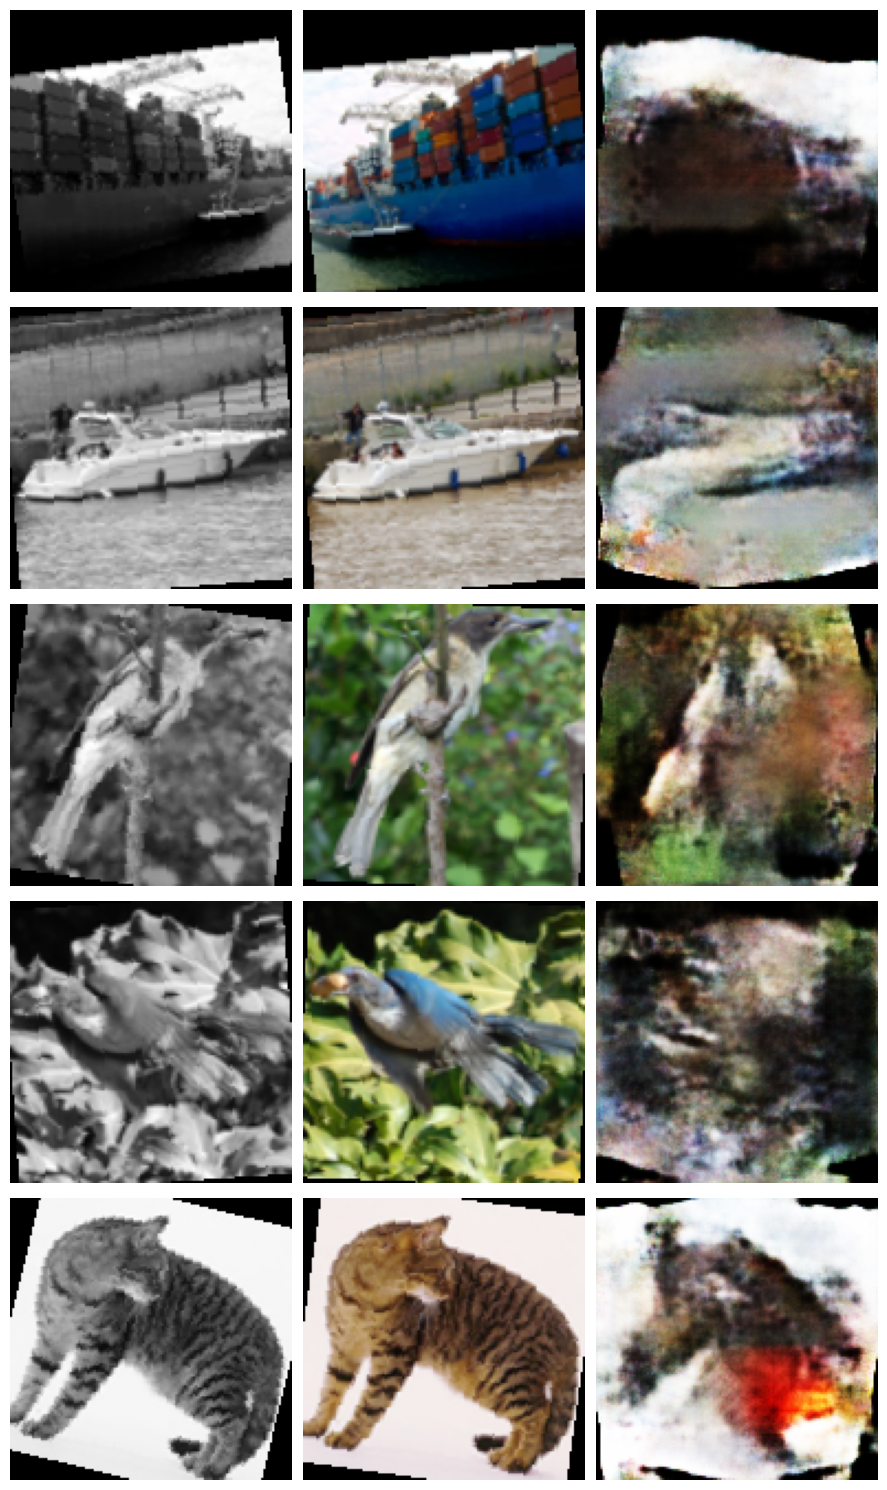

In [18]:
n = 5
idxs = random.sample(range(len(test_ds)), n)
fig, axs = plt.subplots(n,3, figsize=(9,3*n))

for i, idx in enumerate(idxs):
    gray, rgb = test_ds[idx]
    with torch.no_grad():
        pred = gen(gray.unsqueeze(0).to(device)).cpu().squeeze(0)
    axs[i,0].imshow(gray.squeeze(0), cmap='gray'); axs[i,0].axis('off')
    axs[i,1].imshow(rgb.permute(1,2,0));         axs[i,1].axis('off')
    axs[i,2].imshow(pred.permute(1,2,0));       axs[i,2].axis('off')

plt.tight_layout(); plt.show()
